# Analyst Agent Workflow with LangGraph

This notebook demonstrates a sophisticated agentic workflow using **LangGraph**. It implements an **Analyst Agent** capable of planning, researching, and synthesizing information with advanced features like:

- **Send Map-Reduce**: Dynamic parallel execution of research tasks.
- **Human-in-the-Loop (HITL)**: Interruption for review and approval of plans (Defer concept).
- **Sub-Graphs**: Encapsulated logic for individual research tasks.
- **Asymmetric Parallel Processing**: Parallel branches with different execution times, synchronized using `defer=True`.
- **Persistent Memory**: Long-term state persistence using SQLite.
- **State-Based Routing**: Dynamic control flow based on agent decisions.

## 1. Setup and Initialization
We start by importing necessary libraries and setting up the environment. Ensure you have your `OPENAI_API_KEY` in a `.env` file.

In [8]:
import operator
import asyncio
import sqlite3
from typing import Annotated, List, TypedDict, Dict, Any, Optional
from dotenv import load_dotenv

load_dotenv()

from langchain_community.tools import DuckDuckGoSearchRun
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send, Command, interrupt
from langgraph.checkpoint.sqlite.aio import AsyncSqliteSaver

# Initialize Tools & LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
search_tool = DuckDuckGoSearchRun()

## 2. Research Sub-Graph
This sub-graph acts as a specialized worker. It takes a query, performs a search, and summarizes the result. This encapsulates the research logic, making the main graph cleaner.

In [9]:
# --- Sub-Graphs (Research Worker) ---
class ResearchState(TypedDict):
    query: str
    result: str

def search_step(state: ResearchState):
    # Nodes with Tool Calls
    print(f"  [Sub-Graph] executing tool: {state['query']}")
    try:
        res = search_tool.run(state["query"])
    except Exception as e:
        res = f"Error: {e}"
    return {"result": res}

def summarize_step(state: ResearchState):
    # Process the raw result (Short-term memory usage)
    summary = llm.invoke(f"Summarize in 1 sentence: {state['result']}")
    return {"result": summary.content}

sub_builder = StateGraph(ResearchState)
sub_builder.add_node("search", search_step)
sub_builder.add_node("summarize", summarize_step)
sub_builder.add_edge(START, "search")
sub_builder.add_edge("search", "summarize")
sub_builder.add_edge("summarize", END)
research_graph = sub_builder.compile()

## 3. Main Agent State
The `AnalystState` defines the shared memory for the main component of the agent. It includes the topic, plan, collected findings, final report, critiques for parallel processing, and fields for routing decisions.

In [10]:
# --- Main Graph State ---
class AnalystState(TypedDict):
    topic: str
    plan: List[str]
    findings: Annotated[List[str], operator.add]
    final_report: str
    # Concept: Parallel Node Aggregation
    critiques: Annotated[List[str], operator.add] 
    feedback: Optional[str] # For replanning
    decision: Optional[str] # For routing

## 4. Core Node Logic
Here we define the primary nodes:
- **Planner**: Generates search queries. Handles replanning based on feedback.
- **Human Review (HITL)**: Interrupts execution to ask for user approval. Uses the **Defer** concept.
- **Dispatcher**: Manages the "fan-out" to parallel researchers.
- **Researcher**: Invokes the `research_graph` for a specific query.
- **Synthesizer**: Aggregates findings into a draft report.

In [11]:
# 1. Planner Node
def planner(state: AnalystState):
    print(f"--- 1. Planner: Generating plan for '{state['topic']}' ---")
    
    prompt = f"Generate 2 specific, short search queries for: {state['topic']}."
    if state.get("feedback"):
        print(f"    (Refining plan based on feedback: {state['feedback']})")
        prompt += f"\nIMPORTANT: The user rejected the previous plan. Feedback: {state['feedback']}. Update queries accordingly."
        
    res = llm.invoke(prompt)
    generated_plan = [line.strip().strip('- "') for line in res.content.split('\n') if line.strip()]
    # Clear decision/feedback when generating new plan
    return {"plan": generated_plan, "feedback": None, "decision": None} 

# 2. Human in the Loop Node
# Concept: Defer (The graph pauses/defers execution to an external actor)
def human_review_node(state: AnalystState):
    print("--- 2. HITL: Interrupting for review (Concept: Defer) ---")
    
    # 3. Interrupt
    review_result = interrupt({
        "task": "review_plan",
        "generated_plan": state["plan"]
    })
    
    # Logic based on human feedback
    # We return STATE UPDATES, not Commands. The conditional edge handles routing.
    if isinstance(review_result, dict) and "feedback" in review_result:
        print(f"--- 2.1. Plan Rejected. Looping back to planner. ---")
        return {"decision": "reject", "feedback": review_result["feedback"]}
    
    print(f"--- 2.1. Plan Approved: {state['plan']} ---")
    return {"decision": "approve"}

# 3. Send Map Reduce (The Map Step)
# 7. Parallel Processing (Edge Logic)
def map_reduce_logic(state: AnalystState):
    print(f"--- 3. Dispatching {len(state['plan'])} researchers (Parallel) ---")
    # Returns list of Send objects (Dynamic Fan-out)
    return [Send("researcher", {"query": q}) for q in state["plan"]]

# Dummy Node to anchor the routing
def researcher_dispatcher_node(state: AnalystState):
    return {}

# Sub-graph Wrapper Node
def researcher_node(state: dict):
    # 6. Sub-Graphs (Invoking compiled graph)
    print(f"--- [Researcher Node] Invoking Sub-Graph for: {state['query']} ---")
    output = research_graph.invoke({"query": state["query"]})
    return {"findings": [f"Query: {state['query']} -> {output['result']}"]}

# Reducer
def synthesizer(state: AnalystState):
    print("--- 4. Synthesizer (Reduce) ---")
    context = "\n".join(state["findings"])
    prompt = f"Draft a report based on:\n{context}"
    res = llm.invoke(prompt)
    return {"final_report": res.content}

## 5. Advanced Parallel Processing & Defer
We implement an **asymmetric parallel processing** pattern. After synthesis, the workflow splits into two parallel branches with different execution times:
1.  **Branch 1 (Slow)**: `style_critic_1` -> `style_critic_2`. This multi-step process simulates a long-running task.
2.  **Branch 2 (Fast)**: `fact_critic`. This runs quickly.

The **Publisher** node is configured with `defer=True`. This ensures it **waits** for ALL parallel branches in the current superstep to complete before executing, acting as a synchronization barrier.

In [12]:
# Concept: Parallel Node Execution (Branch 1 - Slow Step 1)
async def style_critic_1(state: AnalystState):
    print("--- 5a-1. Style Critic Step 1 (Analysis) ---")
    await asyncio.sleep(2) 
    return {} # Pass

# Concept: Parallel Node Execution (Branch 1 - Slow Step 2)
async def style_critic_2(state: AnalystState):
    print("--- 5a-2. Style Critic Step 2 (Suggestion) ---")
    await asyncio.sleep(2) 
    return {"critiques": ["Style Review: Tone is professional (Multi-step verification)."]}

# Concept: Parallel Node Execution (Branch 2 - Fast)
async def fact_critic(state: AnalystState):
    print("--- 5b. Fact Critic (Parallel Branch - Fast) ---")
    # Simulate shorter processing time
    await asyncio.sleep(1)
    return {"critiques": ["Fact Review: Sources citations needed."]}

# Final Aggregator
# Concept: Delayed Parallel Processing with defer=True
# This node will wait until ALL branches in the current superstep (critics) are done.
def publisher(state: AnalystState):
    print("--- 6. Publisher (Final Polish - Deferred) ---")
    final_output = f"{state['final_report']}\n\n--- CRITIQUES ---\n" + "\n".join(state["critiques"])
    return {"final_report": final_output}

## 6. Graph Construction
We assemble the nodes and define the routing logic. This includes explicit edges for visual clarity and conditional edges for dynamic routing.

In [13]:
# Builder
builder = StateGraph(AnalystState)
builder.add_node("planner", planner)
builder.add_node("human_review", human_review_node)
builder.add_node("researcher_dispatcher", researcher_dispatcher_node)
builder.add_node("researcher", researcher_node)
builder.add_node("synthesizer", synthesizer)
# New nodes for Asymmetric Branching
builder.add_node("style_critic_1", style_critic_1)
builder.add_node("style_critic_2", style_critic_2)
builder.add_node("fact_critic", fact_critic)

# Using defer=True for delayed parallel processing synchronization
builder.add_node("publisher", publisher, defer=True)

builder.add_edge(START, "planner")
builder.add_edge("planner", "human_review")

# Visual & Runtime Edge Definitions
# State-based routing function
def route_review(state: AnalystState):
    if state.get("decision") == "reject":
        return "planner"
    return "researcher_dispatcher"

builder.add_conditional_edges(
    "human_review", 
    route_review, 
    ["researcher_dispatcher", "planner"]
)

builder.add_conditional_edges("researcher_dispatcher", map_reduce_logic,  ["researcher"])
builder.add_edge("researcher", "synthesizer")

# ASYMMETRIC PARALLEL BRANCHING
# Branch 1 (Long): synthesizer -> style_critic_1 -> style_critic_2 -> publisher
builder.add_edge("synthesizer", "style_critic_1")
builder.add_edge("style_critic_1", "style_critic_2")
builder.add_edge("style_critic_2", "publisher")

# Branch 2 (Short): synthesizer -> fact_critic -> publisher
builder.add_edge("synthesizer", "fact_critic")
builder.add_edge("fact_critic", "publisher")

builder.add_edge("publisher", END)

## 7. Visualization
We visualize the graph structure using Mermaid.

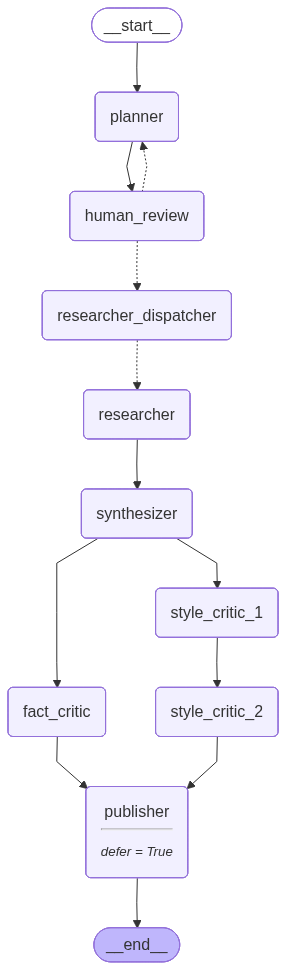

In [14]:
from IPython.display import Image, display

# Compile the graph for visualization (No checkpointer needed for static execution graph)
graph = builder.compile()

# Generate Image
try:
    png_bytes = graph.get_graph().draw_mermaid_png()
    with open("agent_graph.png", "wb") as f:
        f.write(png_bytes)
    display(Image("agent_graph.png"))
except Exception as e:
    print(f"Graph visualization failed: {e}")

## 8. Execution Loop
Run the agent workflow. This loop handles the Human-in-the-Loop interaction by pausing for input when an interrupt occurs.

In [15]:
# Execution
async def main():
    async with AsyncSqliteSaver.from_conn_string("agent_state.db") as checkpointer:
        # Compile WITH checkpointer for the actual run
        graph = builder.compile(checkpointer=checkpointer)
        
        # 11. Short-Term memory (Thread ID segments sessions)
        config = {"configurable": {"thread_id": "session_notebook_2"}}
        
        print(">>> Starting Workflow...")
        
        # Initial Run
        curr_input = {"topic": "Quantum Computing Trends 2024"}
        curr_command = None
        
        while True:
            try:
                # If we have a command (resume), use it, otherwise use input
                if curr_command:
                    input_to_stream = curr_command
                    curr_command = None # Reset
                elif curr_input:
                    input_to_stream = curr_input
                    curr_input = None # Reset
                else:
                    input_to_stream = None 

                async for event in graph.astream(input_to_stream, config, stream_mode="updates"):
                    for k, v in event.items():
                        print(f"  [Update] Node: {k}")
                        if v and "final_report" in v and k == "publisher":
                             print(f"\nFINAL REPORT:\n{v['final_report']}")
                
                # Check state
                snapshot = await graph.aget_state(config)
                if snapshot.next:
                     # Check for interrupts
                     if snapshot.tasks and snapshot.tasks[0].interrupts:
                         interrupt_value = snapshot.tasks[0].interrupts[0].value
                         print(f"\n!!! PAUSED: {interrupt_value['task']} !!!")
                         print(f"Plan to review: {interrupt_value['generated_plan']}")
                         
                         # Real Human Input
                         user_input = input("Approve plan? (y/n): ")
                         
                         if user_input.lower() in ["y", "yes"]:
                             print(">>> Approving plan...")
                             curr_command = Command(resume="approved")
                         else:
                             feedback = input("Please provide feedback for replanning: ")
                             print(f">>> Rejecting plan with feedback: {feedback}...")
                             curr_command = Command(resume={"feedback": feedback})
                         
                         continue
                
                # If no next, we are done
                print(">>> Workflow Finished.")
                break
                
            except Exception as e:
                print(f"Error executing graph: {e}")
                import traceback
                traceback.print_exc()
                break

# Run the main loop
await main()

>>> Starting Workflow...
--- 1. Planner: Generating plan for 'Quantum Computing Trends 2024' ---
  [Update] Node: planner
--- 2. HITL: Interrupting for review (Concept: Defer) ---
  [Update] Node: __interrupt__

!!! PAUSED: review_plan !!!
Plan to review: ['1. "Quantum computing trends 2024 predictions', '2. "Emerging technologies in quantum computing 2024']
>>> Rejecting plan with feedback: Indian Economy and Stock Market in 2026...
--- 2. HITL: Interrupting for review (Concept: Defer) ---
--- 2.1. Plan Rejected. Looping back to planner. ---
  [Update] Node: human_review
--- 1. Planner: Generating plan for 'Quantum Computing Trends 2024' ---
    (Refining plan based on feedback: Indian Economy and Stock Market in 2026)
  [Update] Node: planner
--- 2. HITL: Interrupting for review (Concept: Defer) ---
  [Update] Node: __interrupt__

!!! PAUSED: review_plan !!!
Plan to review: ['1. "Indian economy growth forecast 2026', '2. "Stock market predictions India 2026']
>>> Approving plan...
--